In [1]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import average_precision_score

In [2]:
# Load the CICIDS 2017 dataset (assuming the dataset is in CSV format)
# Make sure to load your dataset path here
df = pd.read_csv('cicids2017_cleaned.csv')

In [3]:
df.shape

(2520751, 53)

In [4]:
df.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [5]:
# Assuming the target column is 'Label' and features are the rest
X = df.drop(columns=['Attack Type'])
y = df['Attack Type']

# Encode labels if necessary
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [6]:
# Split the dataset into train, validation, and test sets (70%, 15%, 15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [11]:
# Initialize LightGBM model
lgb_model = lgb.LGBMClassifier(num_class=len(np.unique(y_encoded)), objective='multiclass', metric='multi_logloss')

# Train the model
early_stopping_callback = lgb.callback.early_stopping(stopping_rounds=50)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[early_stopping_callback])

# Make predictions
y_pred = lgb_model.predict(X_test)
y_pred_prob = lgb_model.predict_proba(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')




[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.096842 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12016
[LightGBM] [Info] Number of data points in the train set: 1764525, number of used features: 52
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -7.164482
[LightGBM] [Info] Start training from score -5.622155
[LightGBM] [Info] Start training from score -2.981476
[LightGBM] [Info] Start training from score -2.566901
[LightGBM] [Info] Start training from score -0.184666
[LightGBM] [Info] Start training from score -3.327215
[LightGBM] [Info] Start training from score -7.077532
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with p

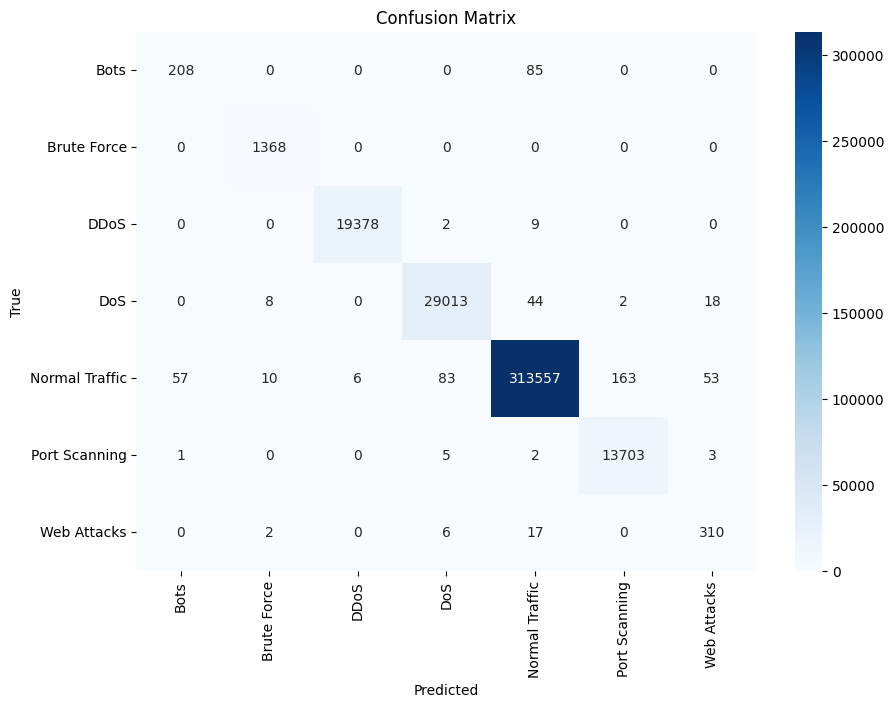

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



In [13]:
# Precision, Recall, F1 Score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')



Precision: 0.9985
Recall: 0.9985
F1 Score: 0.9985


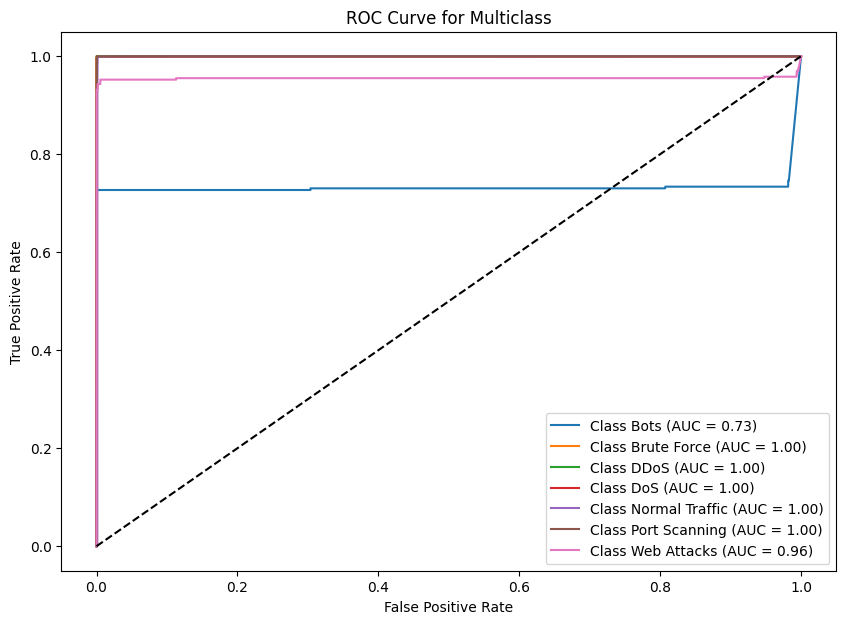

In [14]:
# ROC Curve for multiclass (One-vs-Rest approach)
fpr, tpr, roc_auc = {}, {}, {}
n_classes = len(np.unique(y_encoded))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 7))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for Multiclass')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()



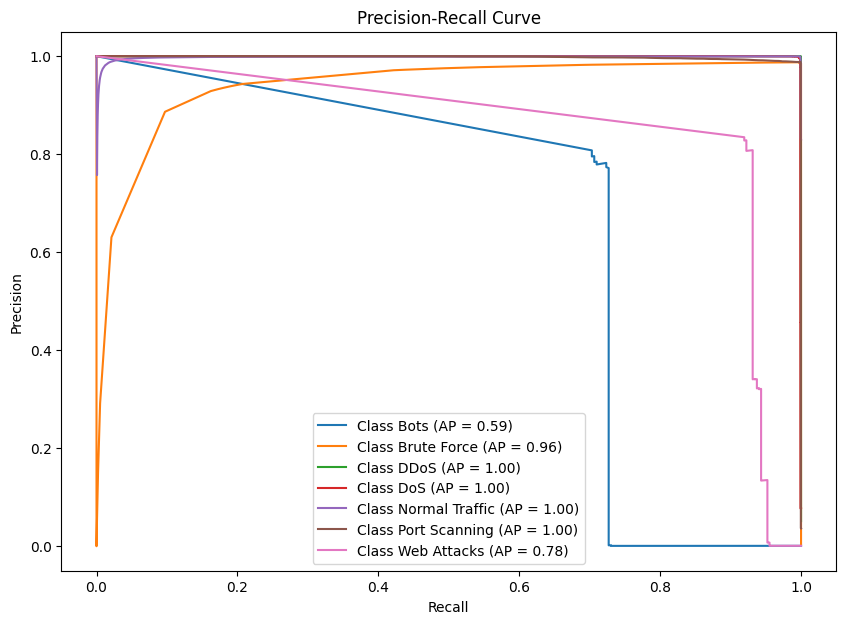

In [15]:
# Precision-Recall Curve
plt.figure(figsize=(10, 7))
for i in range(n_classes):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test == i, y_pred_prob[:, i])
    avg_precision = average_precision_score(y_test == i, y_pred_prob[:, i])
    plt.plot(recall_vals, precision_vals, label=f'Class {label_encoder.classes_[i]} (AP = {avg_precision:.2f})')

plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.show()